# Simple Linear Regression — Salary Prediction
### ML Development Cycle
**Steps Covered:**
1. Problem Definition
2. Data Collection & Loading
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Selection
6. Model Building
7. Model Training
8. Model Evaluation
9. Visualization

## Problem Definition

**Goal:** Build a Simple Linear Regression model to predict an employee's **Salary** based on their **Years of Experience**.

## Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv('Salary_Data.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns')
df.head(10)

Shape: (6704, 6)  →  6704 rows, 6 columns


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


## Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [5]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [6]:
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

Total missing values: 17


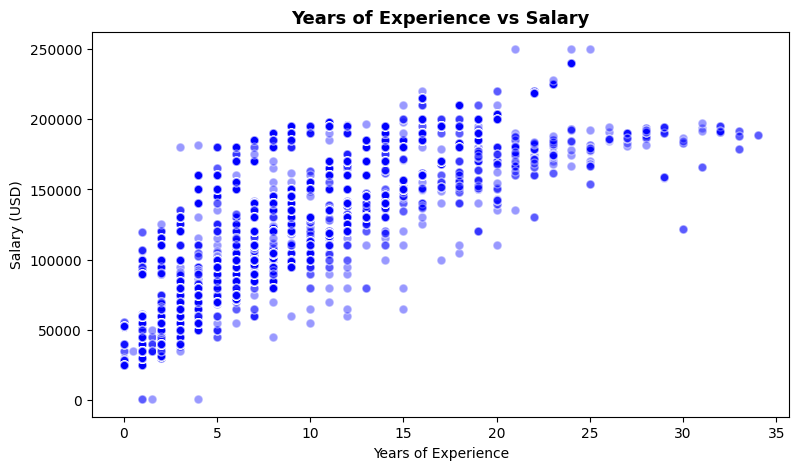

In [7]:
plt.figure(figsize=(9, 5))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.4, color='blue', edgecolors='white', s=40)
plt.title('Years of Experience vs Salary', fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.show()

## Data Preprocessing

In [8]:
df_clean = df[['Years of Experience', 'Salary']].dropna()
print(f'Shape after dropping NaN:  {df_clean.shape}')
df_clean.head()

Shape after dropping NaN:  (6699, 2)


,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [9]:
print(f'Duplicates before removal: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()
print(f'Shape after duplicate removal: {df_clean.shape}')

Duplicates before removal: 5954
Shape after duplicate removal: (745, 2)


In [19]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [11]:
def detect_outliers_iqr(col, data):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers, lower, upper

for col in ['Years of Experience', 'Salary']:
    outliers, lower, upper = detect_outliers_iqr(col, df_clean)
    print(f'[{col}]  Lower bound: {lower:.2f}  |  Upper bound: {upper:.2f}  |  Outliers found: {len(outliers)}')

[Years of Experience]  Lower bound: -13.00  |  Upper bound: 35.00  |  Outliers found: 0
[Salary]  Lower bound: -26507.50  |  Upper bound: 287904.50  |  Outliers found: 0


## Feature Selection & Data Splitting

In [12]:
X = df_clean[['Years of Experience']]  
y = df_clean['Salary']

print(f'Feature shape (X): {X.shape}')
print(f'Target shape  (y): {y.shape}')
print(f'\nSample X values:\n{X.head()}')
print(f'\nSample y values:\n{y.head()}')

Feature shape (X): (745, 1)
Target shape  (y): (745,)

Sample X values:
   Years of Experience
0                  5.0
1                  3.0
2                 15.0
3                  7.0
4                 20.0

Sample y values:
0     90000.0
1     65000.0
2    150000.0
3     60000.0
4    200000.0
Name: Salary, dtype: float64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.20,random_state=42)

print(f'Training set size:  {X_train.shape[0]} samples')
print(f'Test set size:      {X_test.shape[0]} samples')

Training set size:  596 samples
Test set size:      149 samples


---
## Step 6 & 7 — Model Building & Training

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model training complete!')
print(f'\n  Intercept  (c) : {model.intercept_:,.2f}')
print(f'  Coefficient (m) : {model.coef_[0]:,.2f}')

Model training complete!

  Intercept  (c) : 72,048.69
  Coefficient (m) : 4,878.94


## Model Evaluation

In [15]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mae_train  = mean_absolute_error(y_train, y_pred_train)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train   = r2_score(y_train, y_pred_train)

mae_test   = mean_absolute_error(y_test, y_pred_test)
mse_test   = mean_squared_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mse_test)
r2_test    = r2_score(y_test, y_pred_test)

print(f'         TRAINING SET METRICS')

print(f'  MAE  (Mean Absolute Error)        : {mae_train:>12,.2f}')
print(f'  MSE  (Mean Squared Error)         : {mse_train:>12,.2f}')
print(f'  RMSE (Root Mean Squared Error)    : {rmse_train:>12,.2f}')
print(f'  R²   (Coefficient of Determination): {r2_train:>12.4f}')
print()
print(f'         TEST SET METRICS')
print(f'  MAE  (Mean Absolute Error)        : {mae_test:>12,.2f}')
print(f'  MSE  (Mean Squared Error)         : {mse_test:>12,.2f}')
print(f'  RMSE (Root Mean Squared Error)    : {rmse_test:>12,.2f}')
print(f'  R²   (Coefficient of Determination): {r2_test:>12.4f}')

         TRAINING SET METRICS
  MAE  (Mean Absolute Error)        :    23,051.32
  MSE  (Mean Squared Error)         : 919,802,048.22
  RMSE (Root Mean Squared Error)    :    30,328.24
  R²   (Coefficient of Determination):       0.6053

         TEST SET METRICS
  MAE  (Mean Absolute Error)        :    24,009.64
  MSE  (Mean Squared Error)         : 951,621,127.61
  RMSE (Root Mean Squared Error)    :    30,848.36
  R²   (Coefficient of Determination):       0.5934


## Visualization

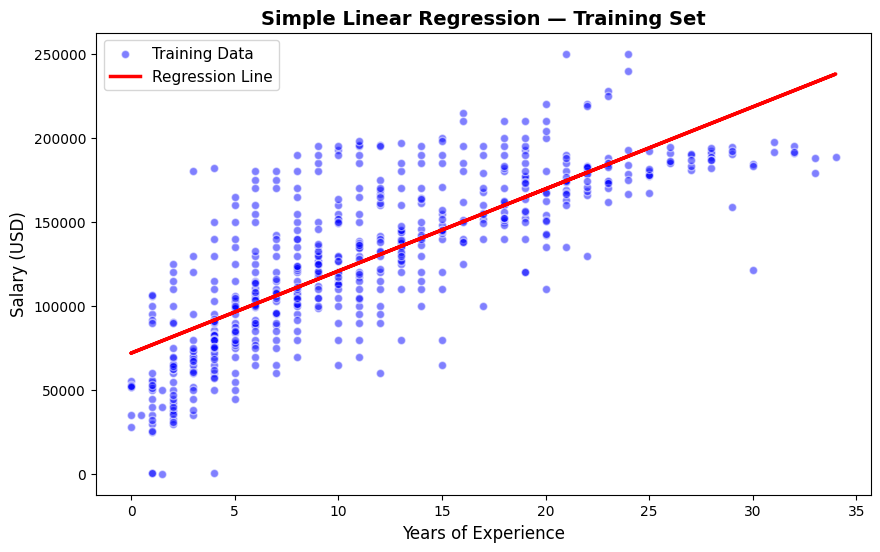

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, s=35, label='Training Data', edgecolors='white')
plt.plot(X_train, y_pred_train, color='red', linewidth=2.5, label='Regression Line')
plt.title('Simple Linear Regression — Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.show()

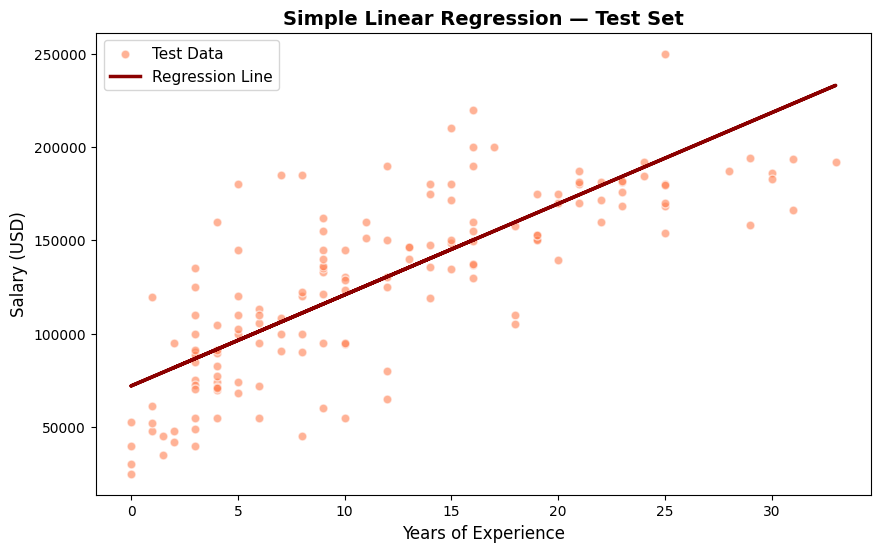

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='coral', alpha=0.6, s=40, label='Test Data', edgecolors='white')
plt.plot(X_test, y_pred_test, color='darkred', linewidth=2.5, label='Regression Line')
plt.title('Simple Linear Regression — Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.show()

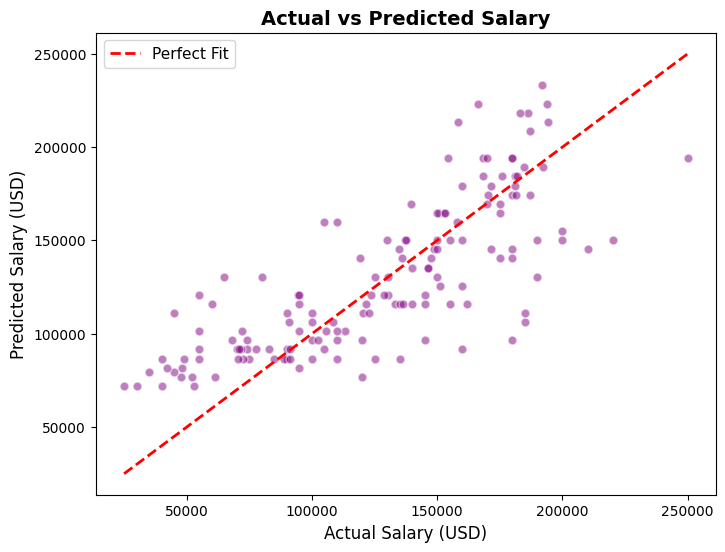

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='purple', alpha=0.5, s=40, edgecolors='white')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Fit')

plt.title('Actual vs Predicted Salary', fontsize=14, fontweight='bold')
plt.xlabel('Actual Salary (USD)', fontsize=12)
plt.ylabel('Predicted Salary (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.show()